In [ ]:
#Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

MSE: 0.5688, RMSE: 0.7542, R2: 0.5449


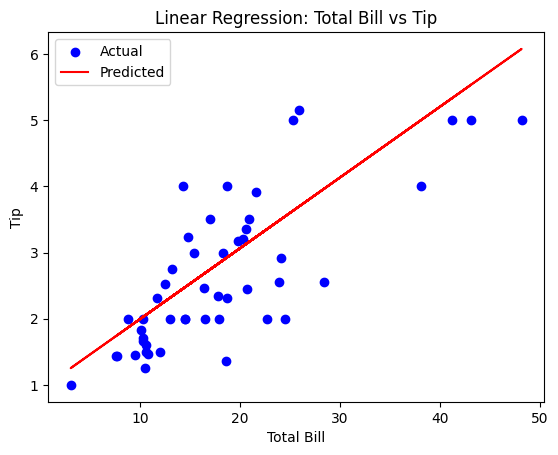

In [ ]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

data = sns.load_dataset('tips')
X = data[['total_bill']].values
y = data['tip'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}')

plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Linear Regression: Total Bill vs Tip')
plt.legend()
plt.show()

In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score

data['sex_enc'] = LabelEncoder().fit_transform(data['sex'])
X2 = data[['total_bill', 'size', 'sex_enc']].values
y2 = LabelEncoder().fit_transform(data['smoker'])

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train2 = scaler.fit_transform(X_train2)
X_test2 = scaler.transform(X_test2)

clf = LogisticRegression()
clf.fit(X_train2, y_train2)
y_pred2 = clf.predict(X_test2)

print('Accuracy:', accuracy_score(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2))

Accuracy: 0.6530612244897959
              precision    recall  f1-score   support

           0       0.66      0.94      0.77        31
           1       0.60      0.17      0.26        18

    accuracy                           0.65        49
   macro avg       0.63      0.55      0.52        49
weighted avg       0.64      0.65      0.59        49



### Confusion Matrix for Logistic Regression

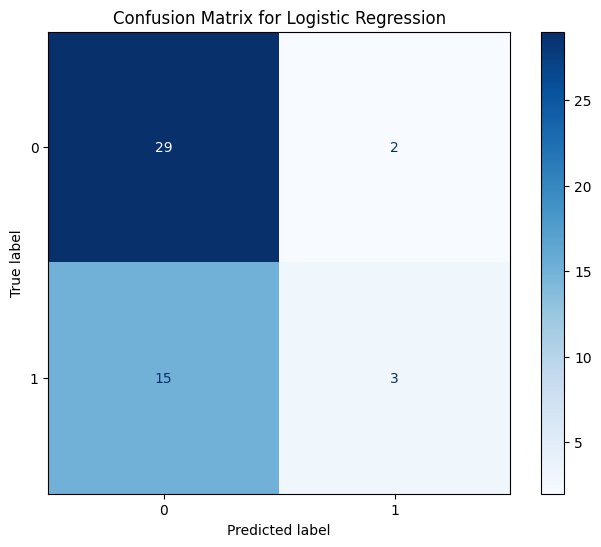

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(clf, X_test2, y_test2, cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix for Logistic Regression')
plt.show()